In [8]:
import xml.etree.ElementTree as ET
import pandas as pd
import os

def parse_xunit_xml_to_csv(xml_folder, output_csv_path):
    """
    Parses xUnit XML reports and extracts test names, durations, and outcomes.
    Test type is determined by the test class name:
      - ProductServiceTests  -> Mocked_Dependency  (uses Moq, no DB)
      - ProductRepositoryTests -> InMemory_Repository (uses EF Core InMemoryDatabase)
    """
    extracted_data = []

    for filename in os.listdir(xml_folder):
        if filename.endswith('.xml'):
            file_path = os.path.join(xml_folder, filename)

            try:
                tree = ET.parse(file_path)
                root = tree.getroot()

                for test_case in root.iter('test'):
                    test_name = test_case.attrib.get('name', 'Unknown_Test')
                    execution_time = float(test_case.attrib.get('time', 0.0))
                    result = test_case.attrib.get('result', 'Pass')

                    # Categorize by class name, not test name keywords.
                    # ProductServiceTests uses Moq to mock IProductRepository -> Mocked_Dependency.
                    # ProductRepositoryTests uses EF Core InMemoryDatabase -> Standard_Logic.
                    if 'ProductServiceTests' in test_name:
                        test_type = 'Mocked_Dependency_Tests'
                    elif 'ProductRepositoryTests' in test_name:
                        test_type = 'Standard_Tests'
                    else:
                        test_type = 'Other'

                    extracted_data.append({
                        'Run_Source': filename,
                        'Test_Name': test_name,
                        'Test_Type': test_type,
                        'Execution_Time_Seconds': execution_time,
                        'Execution_Time_Milliseconds': execution_time * 1000,
                        'Result': result
                    })

            except ET.ParseError:
                print(f"Error parsing {filename}. Is it a valid XML file?")

    if extracted_data:
        df = pd.DataFrame(extracted_data)
        df.to_csv(output_csv_path, index=False)
        print(f"Successfully extracted {len(df)} test records to {output_csv_path}")
        print("\n--- Quick Summary ---")
        print(df.groupby('Test_Type')['Execution_Time_Milliseconds'].agg(['mean', 'median', 'std', 'count']).round(3))
    else:
        print("No test data found. Check your XML files.")

xml_input_directory = './'
csv_output_file = 'tdd_execution_dataset.csv'

print(f"Looking for XML files in: {os.path.abspath(xml_input_directory)}")
parse_xunit_xml_to_csv(xml_input_directory, csv_output_file)

Looking for XML files in: d:\Study\20. Project Seminar\SeminarDemo\github_reports
Successfully extracted 20000 test records to tdd_execution_dataset.csv

--- Quick Summary ---
                    mean  median     std  count
Test_Type                                      
Mocked_Dependency  0.186   0.037   1.003  10000
Standard_Logic     0.684   0.468  14.820  10000


C:\Users\Admin\AppData\Local\Temp\ipykernel_35320\2568214295.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Admin\AppData\Local\Temp\ipykernel_35320\2568214295.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


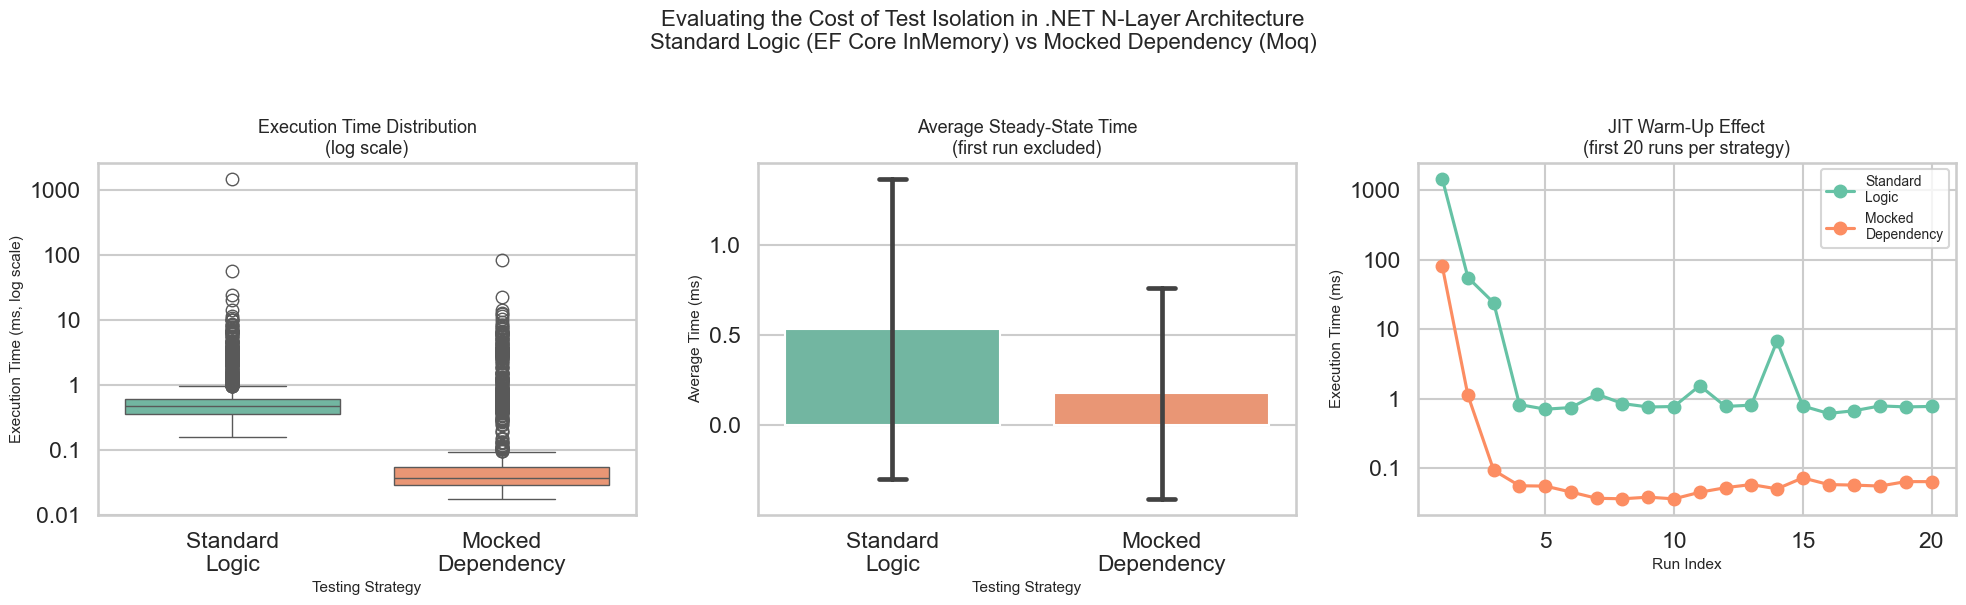

--- Full Distribution (all runs, including warm-up) ---
                    mean  median     std    min       max  count
Test_Type                                                       
Mocked_Dependency  0.186   0.037   1.003  0.018    81.640  10000
Standard_Logic     0.684   0.468  14.820  0.160  1480.178  10000

--- Steady-State (first run excluded per test type) ---
                    mean  median    std    min     max  count
Test_Type                                                    
Mocked_Dependency  0.177   0.037  0.585  0.018  22.520   9999
Standard_Logic     0.536   0.468  0.833  0.160  55.374   9999


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

df = pd.read_csv('tdd_execution_dataset.csv')

sns.set_theme(style='whitegrid', context='talk')

# ── Category order and labels ────────────────────────────────────────────────
order = ['Standard_Tests', 'Mocked_Dependency_Tests']
labels = {
    'Standard_Tests':          'Standard
Tests',
    'Mocked_Dependency_Tests': 'Mocked
Dependency Tests'
}
df['Test_Label'] = df['Test_Type'].map(labels)
label_order = [labels[o] for o in order]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(
    'Evaluating the Cost of Test Isolation in .NET N-Layer Architecture
'
    'Standard Tests (Repository) vs Mocked Dependency Tests (Service Layer)',
    fontsize=16, y=1.02
)

# ── Chart 1: Box plot with log scale ─────────────────────────────────────────
# Log scale is essential because the JIT warm-up spike (~1000+ ms on first run)
# would otherwise collapse the steady-state distribution (~0.5 ms) near zero.
sns.boxplot(
    data=df[df['Test_Type'].isin(order)],
    x='Test_Label', y='Execution_Time_Milliseconds',
    order=label_order, ax=axes[0], palette='Set2'
)
axes[0].set_yscale('log')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
axes[0].set_title('Execution Time Distribution
(log scale)', fontsize=13)
axes[0].set_xlabel('Testing Strategy', fontsize=11)
axes[0].set_ylabel('Execution Time (ms, log scale)', fontsize=11)

# ── Chart 2: Bar plot — steady-state average (warm-up run excluded) ──────────
# The first test executed per class triggers JIT compilation (~1000 ms).
# Excluding it gives a fair comparison of steady-state overhead.
df_sorted = df[df['Test_Type'].isin(order)].copy()
df_sorted['row_idx'] = df_sorted.groupby('Test_Type').cumcount()
df_steady = df_sorted[df_sorted['row_idx'] > 0]  # drop first run per class

sns.barplot(
    data=df_steady,
    x='Test_Label', y='Execution_Time_Milliseconds',
    order=label_order, estimator='mean', errorbar='sd',
    capsize=0.1, ax=axes[1], palette='Set2'
)
axes[1].set_title('Average Steady-State Time
(first run excluded)', fontsize=13)
axes[1].set_xlabel('Testing Strategy', fontsize=11)
axes[1].set_ylabel('Average Time (ms)', fontsize=11)

# ── Chart 3: JIT warm-up — first 20 runs per test type ───────────────────────
# Shows the JIT warm-up spike: the first execution costs orders of magnitude
# more than subsequent ones as .NET compiles the code path on first use.
top_n = 20
warmup_frames = []
for ttype in order:
    subset = df[df['Test_Type'] == ttype].head(top_n).copy()
    subset['Run_Index'] = range(1, len(subset) + 1)
    warmup_frames.append(subset)
df_warmup = pd.concat(warmup_frames)

for ttype, color in zip(order, sns.color_palette('Set2')):
    subset = df_warmup[df_warmup['Test_Type'] == ttype]
    axes[2].plot(
        subset['Run_Index'], subset['Execution_Time_Milliseconds'],
        marker='o', label=labels[ttype], color=color
    )
axes[2].set_title(f'JIT Warm-Up Effect
(first {top_n} runs per strategy)', fontsize=13)
axes[2].set_xlabel('Run Index', fontsize=11)
axes[2].set_ylabel('Execution Time (ms)', fontsize=11)
axes[2].legend(fontsize=10)
axes[2].set_yscale('log')
axes[2].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))

plt.tight_layout()
plt.savefig('tdd_execution_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical summary ───────────────────────────────────────────────────────
print('--- Full Distribution (all runs, including warm-up) ---')
full = df[df['Test_Type'].isin(order)].groupby('Test_Type')['Execution_Time_Milliseconds']     .agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(3)
print(full.to_string())

print('
--- Steady-State (first run excluded per test type) ---')
steady = df_steady.groupby('Test_Type')['Execution_Time_Milliseconds']     .agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(3)
print(steady.to_string())
